In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import make_friedman1
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# Generate the Friedman1 dataset
X, y = make_friedman1(n_samples=5000, n_features=5, random_state=315)

# Convert to DataFrame
X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(5)])
y_series = pd.Series(y, name='label')

# Combine into a single DataFrame for easy exploration
df = X_df.copy()
df['label'] = y_series

# Display the first few rows
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,label
0,0.616679,0.279165,0.125676,0.315648,0.996900,16.091937
1,0.423093,0.112483,0.981730,0.719996,0.999457,18.328074
2,0.409812,0.596355,0.087318,0.646466,0.138363,17.508035
3,0.824479,0.906551,0.373458,0.400470,0.618359,14.544648
4,0.856326,0.250800,0.535109,0.944498,0.958171,20.507191


rmse for test = 0.0002411871377630834
rmse for train = 0.0002309094545203058
76.5**2 * RBF(length_scale=[3.39, 3.59, 27.8, 176, 1.3e+03]) + WhiteKernel(noise_level=1e-10)


c:\Users\justi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


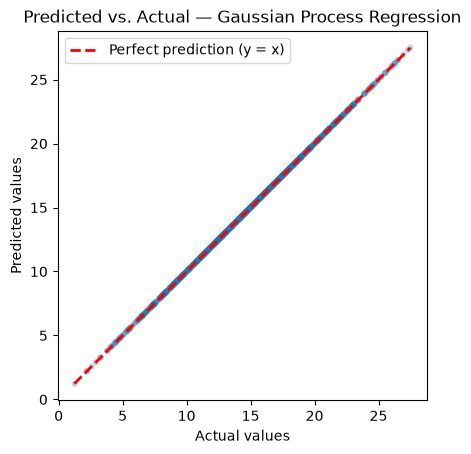

In [ ]:
#adding n_features, noise_level_bounds and standard scale improved test/train from .04/.04 to .00024/.00023
X_train, X_test, y_train, y_test = train_test_split(X_df, y_series, test_size=0.2, random_state=315)
X_train_sub, y_train_sub = X_train[:500], y_train[:500]

#n_features lets the model look at each feature individually and assign a length scale to each one. This is important because some features may be more important than others, and the model can learn this by assigning different length scales to each feature.
#length_scale is a hyperparameter that controls how much influence each feature has on the predictions. A smaller length scale means that the model will be more sensitive to changes in that feature, while a larger length scale means that the model will be less sensitive to changes in that feature.
#measures how sensitive the model is to changes in each feature.
n_features = X_train.shape[1]   
kernel = 1.0 * RBF(length_scale=[1.0]*n_features) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e10))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, normalize_y=True, random_state=315)
model = make_pipeline(StandardScaler(), gpr)

model.fit(X_train_sub, y_train_sub)


y_pred_test, y_std = model.predict(X_test, return_std=True)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
print(f'rmse for test = {rmse_test}')

y_pred_train = model.predict(X_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
print(f'rmse for train = {rmse_train}')
print(gpr.kernel_)

plt.scatter(y_test, y_pred_test, alpha=0.3, edgecolors='none', s=20)

lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=2,
         label='Perfect prediction (y = x)')

plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predicted vs. Actual — Gaussian Process Regression')
plt.legend()
plt.axis('square') 
plt.show()

In [21]:
row = pd.DataFrame([{'model': 'GPR', 'train_rmse': rmse_train, 'test_rmse': rmse_test}])
row.to_csv('results.csv', mode='a', header=not os.path.exists('results.csv'), index=False)